## [***Click here to go to the Lab 1***](#lab-1-sleep-health-and-lifestyle-analysis)
## [***Click here to go to the Lab 2***](#lab-2-sleep-health-and-lifestyle-analysis)
## [***Click here to go to the Project***](#project-sleep-health-and-lifestyle-analysis)

# Lab 1: Sleep Health and Lifestyle Analysis
## Data Preprocessing and Exploratory Analysis

### Dataset Information
**Source:** [Kaggle - Sleep Health and Lifestyle Dataset](https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset)

### Aim
To identify the key factors contributing to sleep disorders and poor sleep quality.

### Objectives
1. To evaluate the relationship between sleep duration, sleep quality, and stress levels.
2. To identify which occupations experience the highest levels of stress and physical activity.
3. To determine how health factors (Age, BMI, and Heart Rate) correlate with sleep disorders

## Importing Libraries and Loading Dataset

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Load the dataset
df = pd.read_csv('data/Sleep_health_and_lifestyle_dataset.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print(df)

Dataset Shape: (401, 13)
     Person ID  Gender  Age         Occupation  Sleep Duration  \
0            1    Male   27  Software Engineer             6.1   
1            2    Male   28             Doctor             6.2   
2            3    Male   28             Doctor             6.2   
3            3    Male   28             Doctor             6.2   
4            3    Male   28             Doctor             6.2   
..         ...     ...  ...                ...             ...   
396        370  Female   59              Nurse             4.1   
397        371  Female   59              Nurse             4.0   
398        372  Female   59              Nurse             4.1   
399        373  Female   59              Nurse             4.1   
400        374  Female   59              Nurse             4.1   

     Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
0                   6                       42             5   Overweight   
1                   4       

### 1. Data Preprocessing Technique 1: Missing Data Handling

**Explanation:** We identified rows containing any missing values and removed them completely from the dataset.

**Rationale:**
- Incomplete data (missing values) would mess up our analysis. If sleep duration is missing for someone, we can't analyze their patterns fairly
- We need complete information in each row to compare sleep duration with sleep quality and stress level
- The dataset had 235 missing Sleep Disorder values, which would hide important information about what causes insomnia

**How It Changed the Data:**
- Original dataset: 401 rows
- After removing rows with missing data: 166 rows remained
- Rows removed: 235 rows
- Trade-off: We lost some data but kept only complete, useful records that we can analyze correctly

In [3]:
# Check for missing values
print("Missing Values Count:")
#List all information of our dataframe
df.info()

Missing Values Count:
<class 'pandas.DataFrame'>
RangeIndex: 401 entries, 0 to 400
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                401 non-null    int64  
 1   Gender                   401 non-null    str    
 2   Age                      401 non-null    int64  
 3   Occupation               401 non-null    str    
 4   Sleep Duration           401 non-null    float64
 5   Quality of Sleep         401 non-null    int64  
 6   Physical Activity Level  401 non-null    int64  
 7   Stress Level             401 non-null    int64  
 8   BMI Category             401 non-null    str    
 9   Blood Pressure           401 non-null    str    
 10  Heart Rate               401 non-null    int64  
 11  Daily Steps              401 non-null    int64  
 12  Sleep Disorder           166 non-null    str    
dtypes: float64(1), int64(7), str(5)
memory usage: 40.9 KB


In [4]:
# Display rows that have missing values in any column
rows_with_missing = df[df.isna().any(axis=1)]
print(f"\nTotal rows with missing values: {len(rows_with_missing)}")
print(rows_with_missing[0:234])  # Display all rows with missing values


Total rows with missing values: 235
     Person ID  Gender  Age         Occupation  Sleep Duration  \
0            1    Male   27  Software Engineer             6.1   
1            2    Male   28             Doctor             6.2   
2            3    Male   28             Doctor             6.2   
3            3    Male   28             Doctor             6.2   
4            3    Male   28             Doctor             6.2   
..         ...     ...  ...                ...             ...   
365        339  Female   54           Engineer             8.5   
368        342  Female   56             Doctor             8.2   
369        343  Female   56             Doctor             8.2   
370        344  Female   57              Nurse             8.1   
385        359  Female   59              Nurse             8.0   

     Quality of Sleep  Physical Activity Level  Stress Level   BMI Category  \
0                   6                       42             5     Overweight   
1           

In [5]:
# Count missing values per column shows 235 for sleep disorder
print(df.isnull().sum())
# isna() and isnull() is the same but isna is the newer

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             235
dtype: int64


In [6]:
dropper = df.dropna(axis=0, how='any') # axis=0 for rows, axis=1 for columns
# len() returns the number of elements in an object.
print("old data frame length:", len(df))
print("new data frame length:", len(dropper))
print("Rows with atleast one missing value: ", (len(df) - len(dropper)))

old data frame length: 401
new data frame length: 166
Rows with atleast one missing value:  235


### 2. Data Preprocessing Technique: Outlier Detection

**Explanation:** We'll be using the Interquartile Range (IQR) method to identify extreme values in numeric columns that fall below Q1 - 1.5×IQR or above Q3 + 1.5×IQR.

**Rationale:**
- Outliers (extreme values) can mess up our results. For example, if someone slept only 1 hour or 15 hours, these unusual values would make our averages wrong
- We want to study normal people's sleep patterns, not extreme cases. This helps us understand what really causes insomnia in typical situations
- The IQR method is a fair way to find outliers—it uses the natural spread of data instead of random cutoffs
- Finding outliers helps us spot data errors or unusual cases before we analyze the data

**How It Changed the Data:**
- We found the outliers but didn't delete them yet—we just identified where they are
- Sleep Duration: Normal sleep is 5-9 hours; anything below 2.5 or above 10.5 hours is unusual
- Quality of Sleep: Unusual values are below 3.25 or above 9.75
- Stress Level: Unusual values are below 3.25 or above 8.75
- We can now see which data points are strange and decide later if we should remove them

In [7]:
# Detect outliers using IQR method for numeric columns
print("Outlier Detection using IQR Method:")

numeric_cols = df.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25) #find 25% of data lower percentile
    Q3 = df[col].quantile(0.75) #find 75% of data top percentile
    IQR = Q3 - Q1 #calculate gap between quartiles
    lower_bound = Q1 - 1.5 * IQR # Create a "normal range" by extending the gap by 1.5x on each side
    upper_bound = Q3 + 1.5 * IQR # Create a "normal range" by extending the gap by 1.5x on each side

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)] #Finding  values outside this normal range
    print(f"\n{col}:")
    print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"  Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
    print(f"  Outliers found: {len(outliers)}")

Outlier Detection using IQR Method:

Person ID:
  Q1: 81.00, Q3: 274.00, IQR: 193.00
  Lower Bound: -208.50, Upper Bound: 563.50
  Outliers found: 0

Age:
  Q1: 34.00, Q3: 49.00, IQR: 15.00
  Lower Bound: 11.50, Upper Bound: 71.50
  Outliers found: 0

Sleep Duration:
  Q1: 6.20, Q3: 7.70, IQR: 1.50
  Lower Bound: 3.95, Upper Bound: 9.95
  Outliers found: 0

Quality of Sleep:
  Q1: 6.00, Q3: 8.00, IQR: 2.00
  Lower Bound: 3.00, Upper Bound: 11.00
  Outliers found: 0

Physical Activity Level:
  Q1: 45.00, Q3: 75.00, IQR: 30.00
  Lower Bound: 0.00, Upper Bound: 120.00
  Outliers found: 0

Stress Level:
  Q1: 4.00, Q3: 8.00, IQR: 4.00
  Lower Bound: -2.00, Upper Bound: 14.00
  Outliers found: 0

Heart Rate:
  Q1: 68.00, Q3: 72.00, IQR: 4.00
  Lower Bound: 62.00, Upper Bound: 78.00
  Outliers found: 23

Daily Steps:
  Q1: 5500.00, Q3: 8000.00, IQR: 2500.00
  Lower Bound: 1750.00, Upper Bound: 11750.00
  Outliers found: 0


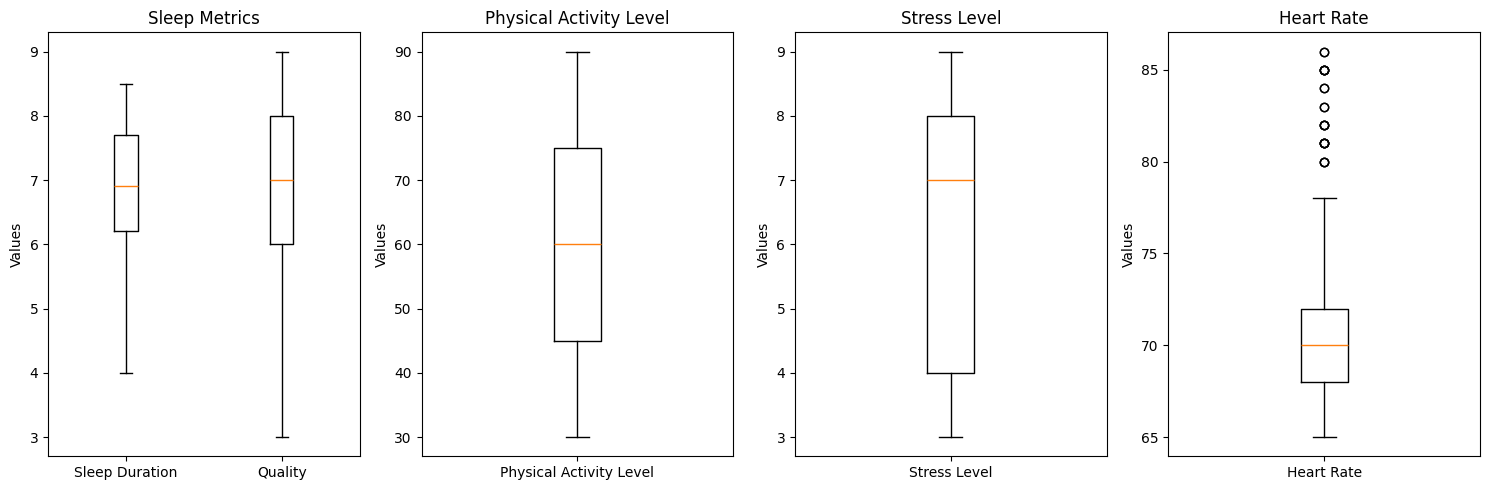

In [8]:
# Create 3 separate boxplots to handle different scales
fig, axes = plt.subplots(1, 4, figsize=(15, 5))

# Plot 1: Sleep-related base on how much they sleep and how good their sleep is
axes[0].boxplot(df[['Sleep Duration', 'Quality of Sleep']])
axes[0].set_title('Sleep Metrics')
axes[0].set_ylabel('Values')
axes[0].set_xticklabels(['Sleep Duration', 'Quality'])

# Plot 2: Physical Activity, Stress and Heart Rate how PA and stress level affect heart rate    
axes[1].boxplot(df[['Physical Activity Level']])
axes[1].set_title('Physical Activity Level')
axes[1].set_ylabel('Values')
axes[1].set_xticklabels(['Physical Activity Level'])

# Plot 3: Stress Level (on its own scale) too low of value compared to other metrics so we put it on its own boxplot
axes[2].boxplot(df[['Stress Level']])
axes[2].set_title('Stress Level')
axes[2].set_ylabel('Values')
axes[2].set_xticklabels(['Stress Level'])

# Plot 4: heart rate (on its own scale) we want to see the outliers in heart rate and how they compare to the normal range of heart rate values
axes[3].boxplot(df[['Heart Rate']])
axes[3].set_title('Heart Rate')
axes[3].set_ylabel('Values')
axes[3].set_xticklabels(['Heart Rate'])

plt.tight_layout()
plt.show()

## 3. Data Preprocessing Technique: Removing duplicates

**Explanation:** We checked for exact duplicate rows where all column values are identical and removed them, keeping only unique records.

**Rationale:**
- Duplicate rows (identical data appearing twice) make our results unreliable. If one person appears twice, they influence our averages too much
- We need each person counted only once to get fair results
- Duplicate records would make some occupations look over-represented and skew the statistics
- Removing duplicates keeps our data clean and trustworthy

**How It Changed the Data:**
- We removed rows that were exact copies of other rows
- Only unique records kept—each person counted once
- Data structure stayed the same; only repetitive rows were deleted
- Now our analysis represents unique individuals fairly

In [9]:
# Check for duplicates
print(f"Duplicate rows found: {df.duplicated().sum()}")
print(df[df.duplicated(keep=False)])  # Show all duplicate rows

# Remove duplicates
#df_clean = dropper.drop_duplicates() # this one is new data after dropper for missing data
df_clean = df.drop_duplicates()
print(f"\nRows before: {len(df)}")
print(f"Rows after: {len(df_clean)}")
print(f"Duplicates removed: {len(df) - len(df_clean)}")
# removing duplicates here, we can see there is 27 dupes, for now we'll just identify which ones but during data processing we'll drop these duplicates
# its best for us to remove the duplicates to keep the data clean and keep its integrity

Duplicate rows found: 27
     Person ID  Gender  Age            Occupation  Sleep Duration  \
2            3    Male   28                Doctor             6.2   
3            3    Male   28                Doctor             6.2   
4            3    Male   28                Doctor             6.2   
6            5    Male   28  Sales Representative             5.9   
7            5    Male   28  Sales Representative             5.9   
8            5    Male   28  Sales Representative             5.9   
10           7    Male   29               Teacher             6.3   
11           7    Male   29               Teacher             6.3   
12           7    Male   29               Teacher             6.3   
13           7    Male   29               Teacher             6.3   
27          21    Male   30                Doctor             6.7   
28          21    Male   30                Doctor             6.7   
29          21    Male   30                Doctor             6.7   
30       

## 4. Data Preprocessing Technique: One-Hot Encoding

**Explanation:** We convert categorical columns into boolean indicator columns (True/False) for each category. This encoding is very common in machine learning and helps algorithms treat nominal data correctly without imposing any order.

**Rationale:**
- Categories like Occupation or Gender have no inherent ranking.
- One-hot encoding preserves all information while avoiding ordinal assumptions.
- It's especially suitable when the number of unique categories is small.

**How It Changes the Data:**
- Original columns are replaced by several new columns (one per category).
- For example, `Gender` becomes `Gender_Male`, `Gender_Female`, etc.

- Each row has a 1 in the column corresponding to its original category and 0 elsewhere. Columns dropped before encoding will not appear in the transformed data.
- The dataset becomes wider but still retains all information.

In [10]:
# One-Hot Encoding example
print("ONE‑HOT ENCODING USING PANDAS GET_DUMMIES")
print("=" * 60)

#dropping unused columns before encoding to avoid crowding the output
cols_to_drop = ['Occupation', 'Blood Pressure']
df_for_encoding = df.drop(columns=cols_to_drop)
print(f"Dropped columns: {cols_to_drop}")
 
#  add a boolean flag for missing Sleep Disorder
if 'Sleep Disorder_empty' not in df.columns:
    df['Sleep Disorder_empty'] = df['Sleep Disorder'].isna()

# perform one-hot encoding on any remaining text columns
categorical_cols = df_for_encoding.select_dtypes(include=['object']).columns.tolist()
print(f"Columns to encode: {categorical_cols}")

df_one_hot = pd.get_dummies(df_for_encoding, columns=categorical_cols)
print(f"Shape before encoding: {df_for_encoding.shape}")
print(f"Shape after encoding:  {df_one_hot.shape}")

# show original columns vs new columns
print(df[0:166])
print("=" * 60)

# show a few of the new columns and sample rows
new_cols = [c for c in df_one_hot.columns if c not in df_for_encoding.columns]
print("New columns created:", new_cols[:10])
print(df_one_hot.head(166))

ONE‑HOT ENCODING USING PANDAS GET_DUMMIES
Dropped columns: ['Occupation', 'Blood Pressure']
Columns to encode: ['Gender', 'BMI Category', 'Sleep Disorder']
Shape before encoding: (401, 11)
Shape after encoding:  (401, 16)
     Person ID  Gender  Age         Occupation  Sleep Duration  \
0            1    Male   27  Software Engineer             6.1   
1            2    Male   28             Doctor             6.2   
2            3    Male   28             Doctor             6.2   
3            3    Male   28             Doctor             6.2   
4            3    Male   28             Doctor             6.2   
..         ...     ...  ...                ...             ...   
161        135    Male   38            Newsman             7.3   
162        136    Male   38             Lawyer             7.3   
163        137  Female   38         Accountant             7.1   
164        138    Male   38        firefighter             7.1   
165        139  Female   38         Accountant      

C:\Users\User\AppData\Local\Temp\ipykernel_131324\3903236325.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_for_encoding.select_dtypes(include=['object']).columns.tolist()


# Lab 2: Sleep Health and Lifestyle Analysis
## Data Analysis and Findings

### Dataset Information
**Source:** [Kaggle - Sleep Health and Lifestyle Dataset](https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset)

### Aim
To identify the key factors contributing to sleep disorders and poor sleep quality.

### Objectives
1. To evaluate the relationship between sleep duration, sleep quality, and stress levels.
2. To identify which occupations experience the highest levels of stress and physical activity.
3. To determine how health factors (Age, BMI, and Heart Rate) correlate with sleep disorders

## Objective 1: To evaluate the relationship between sleep duration, sleep quality, and stress levels.

![alt text](data/dropper.png)

## **Analysis 1: Descriptive Statistics**


In [11]:
# Analysis 1: Descriptive Statistics for Sleep and Stress
# Using 'dropper' which is the cleaned dataframe from Lab 1
sleep_summary = dropper[['Sleep Duration', 'Quality of Sleep', 'Stress Level']].describe()
print("Summary Statistics for Sleep and Stress:")
print(sleep_summary)

Summary Statistics for Sleep and Stress:
       Sleep Duration  Quality of Sleep  Stress Level
count      166.000000        166.000000    166.000000
mean         6.331325          6.216867      6.716867
std          1.086103          1.497863      1.594864
min          4.000000          3.000000      3.000000
25%          6.000000          6.000000      6.000000
50%          6.400000          6.000000      7.000000
75%          6.700000          7.000000      8.000000
max          8.300000          9.000000      9.000000


**Choice of Technique:** I used **Descriptive Statistics** to establish a mathematical baseline for the group’s health. This provides the necessary summary of sleep and stress variables to support my first objective.

**Observation:** With 166 total data points, the numbers show a clear trend:

- Sleep: The average is 6.33 hours, with a median of 6.4 hours. The bottom 25% of the group sleeps 6 hours or less, while even the top 25% only reaches 6.7 hours.

- Quality: The average rating is 6.2/10. The lower 25% of the group reports a quality score of 6.0 or lower, and the top 25% only reaches a 7.0.

- Stress: The average stress level is 6.7/10. Notably, 50% of the group has a high stress score of 7.0 or more, and the top 25% are experiencing very high stress levels of 8.0 to 9.0.

**Interpretation:** The data shows that a vast majority of the group is failing to meet the healthy 7–8 hour sleep target. The narrow range between the 25th and 75th percentiles for sleep (6.0 to 6.7 hours) suggests that poor sleep is a consistent issue across the entire group, rather than just a few individuals.

**Findings:** High stress levels are a dominant characteristic of this group. Since 75% of participants report a stress level of 6.0 or higher, it is highly likely that elevated stress is a primary factor interfering with both the duration and the quality of their sleep.

![alt text](../Imports/RecomSleep.png)

## **Analysis 2: Correlation Heatmap**


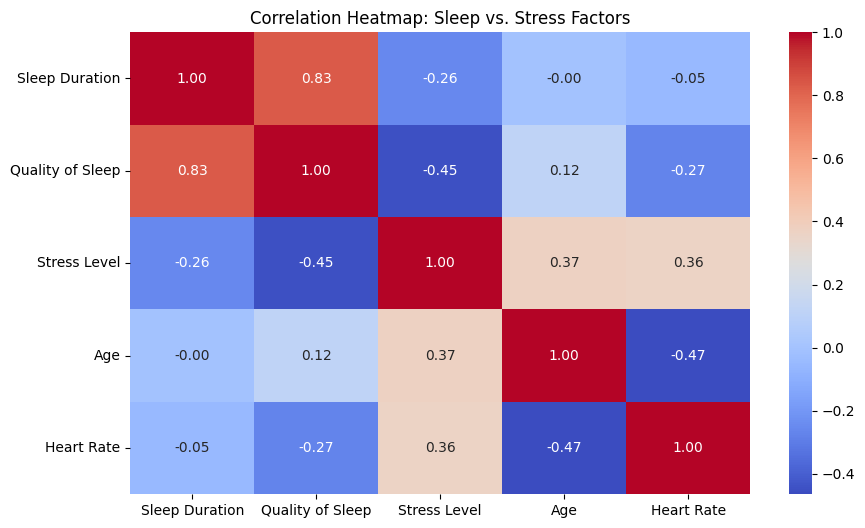

In [12]:
# Analysis 2: Correlation Heatmap (Best Findings)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# We select only numeric columns to find correlations
corr_matrix = dropper[['Sleep Duration', 'Quality of Sleep', 'Stress Level', 'Age', 'Heart Rate']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: Sleep vs. Stress Factors')
plt.show()

**Choice of Technique:** I used a **Correlation Heatmap** to visualize the strength and direction of relationships between all numeric health factors. This method is the most efficient way to achieve my first objective by highlighting which variables (like stress and heart rate) move together.

**Observation:** 
- Stress vs. Sleep Quality: There is a notable negative correlation of (-0.45).

- Stress vs. Sleep Duration: There is also a negative correlation of (-0.26).

- Sleep Duration vs. Quality: A very strong positive correlation of (0.83) exists between how long someone sleeps and how well they sleep.

- Stress vs. Age (0.37): There is a positive correlation here, suggesting that older individuals in this group report higher stress levels.

- Age vs. Heart Rate (-0.47): This shows a moderate negative relationship, where heart rate tends to be lower in the older demographic of the group.

- Heart Rate vs. Stress (0.36): A positive correlation indicates that as stress levels increase, the resting heart rate also tends to rise.

**Interpretation** The data reveals that stress is more damaging to the quality of sleep than the length of sleep. The negative correlation of $-0.45$ suggests that even if a person spends enough hours in bed, high stress levels prevent the body from entering a restful, high-quality state. Furthermore, the link between heart rate and stress ($0.36$) indicates that this stress is a physical burden, not just a mental one.

**Finding:** There is a clear "stress chain" within this group: as participants get older, their reported stress levels increase. This elevated stress leads to higher resting heart rates and a significant drop in sleep quality. This makes older participants a primary high-risk group for poor sleep health and potential cardiovascular strain.

## **Analysis 3: Regression Plot**
#### [***Click here to go back***](#analysis-6-multivariate-2-multiple-linear-regression-to-predict-qos-by-combination-of-stress-level-and-sleep-duration)

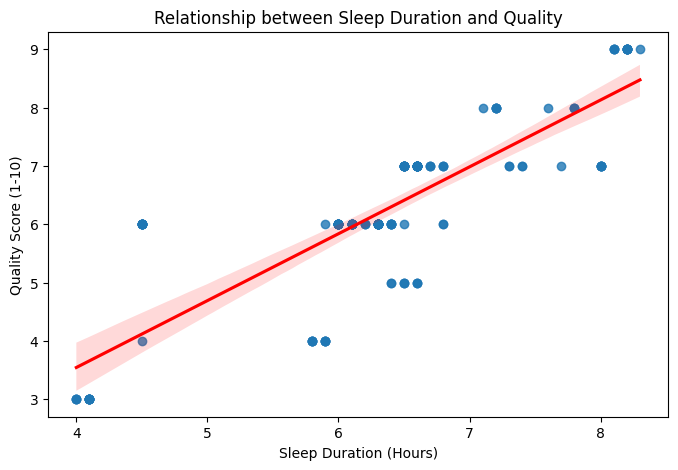

In [13]:
# Analysis 3: Sleep Duration vs Quality of Sleep
plt.figure(figsize=(8, 5))
sns.regplot(x='Sleep Duration', y='Quality of Sleep', data=dropper, line_kws={"color": "red"})
plt.title('Relationship between Sleep Duration and Quality')
plt.xlabel('Sleep Duration (Hours)')
plt.ylabel('Quality Score (1-10)')
plt.show()

**Choice of Technique:** I used a **Regression Plot** to see the trend between hours slept and sleep quality. This supports Objective 1.

**Observation:** 
- There is a clear upward trend in the data points.

- As the x-axis (Sleep Duration) moves from 4 hours toward 8 hours, the y-axis (Quality Score) consistently rises.The red regression line acts as a "best fit," showing a steady increase in quality for every additional hour of sleep gained.

**Interpretation** The plot proves that duration and quality are deeply linked. There is a "tipping point" at 7 hours; once a person hits this mark, quality scores usually stay at 7 or higher. Conversely, sleeping less than 5 hours leads to a "quality crash," where scores rarely get above 4.

**Finding:** Getting enough sleep is the most important factor for feeling rested. Short sleep duration doesn't just mean less rest, it almost guarantees poor quality rest. For this group, increasing total time in bed is the most effective way to improve well-being.

## Objective 2: To identify which occupations experience the highest levels of stress and physical activity.

## **Analysis 4: Bar Plot (Stress Level by Occupation)**


C:\Users\User\AppData\Local\Temp\ipykernel_131324\3768574678.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Occupation', y='Stress Level', data=dropper, palette='viridis', errorbar=None)


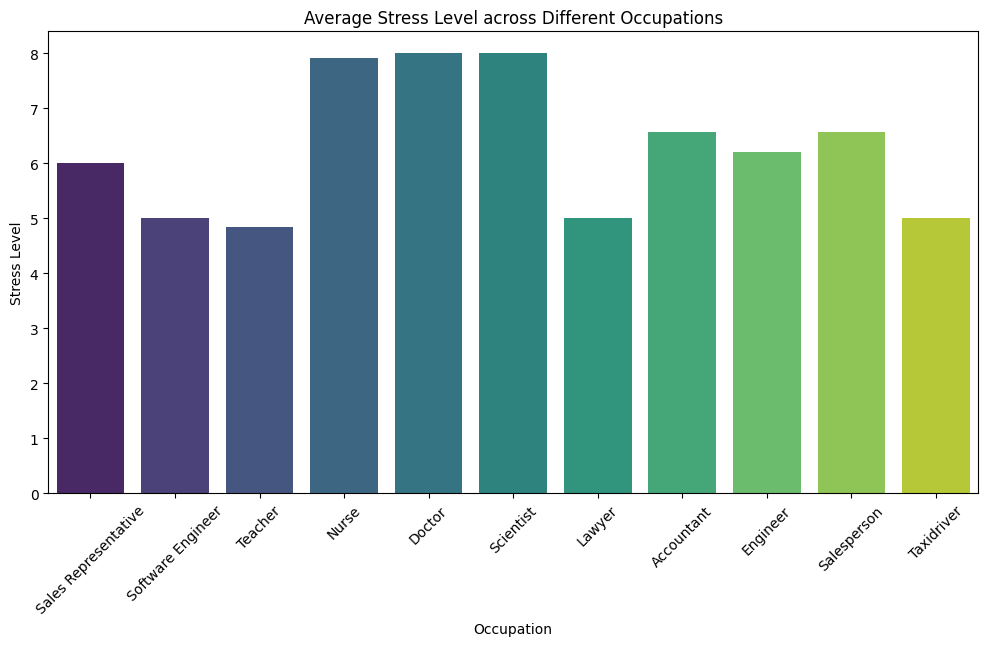

In [14]:
# Analysis 4: Average Stress Level per Occupation (Best Findings)
plt.figure(figsize=(12, 6))
sns.barplot(x='Occupation', y='Stress Level', data=dropper, palette='viridis', errorbar=None)
plt.xticks(rotation=45)
plt.title('Average Stress Level across Different Occupations')
plt.show()

**Choice of Technique:** I used a **Bar Plot** to compare average stress levels across different professions. This directly supports Objective 2 by identifying which occupations are most vulnerable to high stress.

**Observation:** Occupations like Doctors and Nurses and Scientist show the highest stress levels, while teacher is the lowest.

Stress level for each occupation:

- High Stress (7–8): Healthcare professionals (Doctors, Nurses) and Scientists report the highest levels of stress.

- Moderate-High Stress (6–7): Accountants, Engineers, Salespersons, and Sales Representatives.

- Moderate Stress (5–6): Software Engineers, Lawyers, and Taxidrivers.

- Lower Stress (4–5): Teachers reported the lowest average stress levels in this specific dataset.

**Interpretation** Healthcare and scientific roles are the most "high-risk" for stress-related health issues. These professions consistently hit the 8.0 mark, which we previously identified as the top 25% of all stress scores.

**Finding:** Job type is a major predictor of stress. Because these "high-risk" jobs also showed poor sleep quality in earlier analyses, workplace stress is likely the main reason these specific professionals struggle to sleep.

## **Analysis 5: Box Plot (Physical Activity by Occupation)**


c:\Users\User\UBD_CODING\FirstOpeningZomato\.venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 65.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\User\UBD_CODING\FirstOpeningZomato\.venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 65.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\User\UBD_CODING\FirstOpeningZomato\.venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\User\UBD_CODING\FirstOpeningZomato\.venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 30.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\U

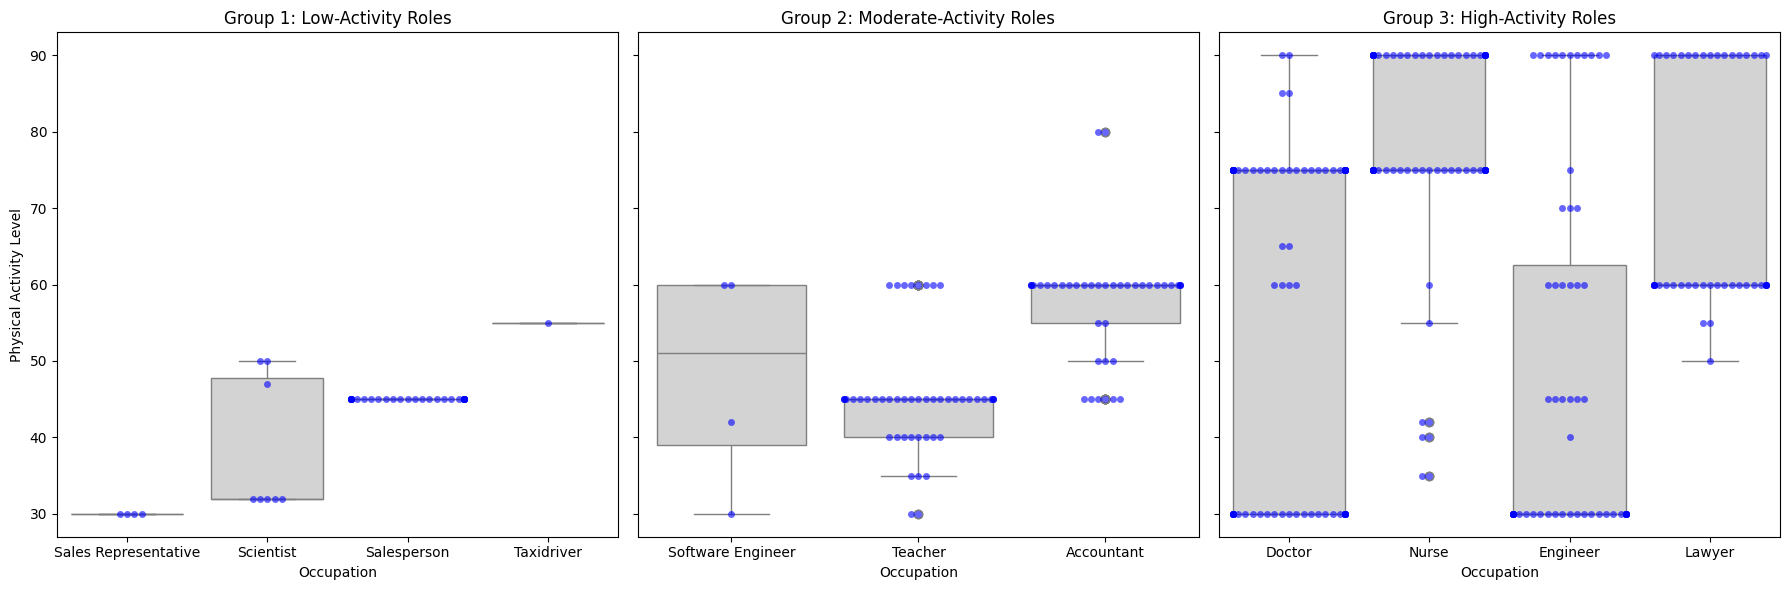

In [15]:
# 1. Create the groups
group1 = ['Sales Representative', 'Scientist', 'Salesperson', 'Taxidriver']
group2 = ['Software Engineer', 'Accountant', 'Teacher']
group3 = ['Nurse', 'Doctor', 'Lawyer', 'Engineer']

# 2. Filter the data into three separate dataframes
df_g1 = df[df['Occupation'].isin(group1)]
df_g2 = df[df['Occupation'].isin(group2)]
df_g3 = df[df['Occupation'].isin(group3)]

# 3. Create the figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True) # sharey keeps the 0-100 scale the same for all

# Plot 1: Group 1
sns.boxplot(x='Occupation', y='Physical Activity Level', data=df_g1, ax=axes[0], color='lightgray')
sns.swarmplot(x='Occupation', y='Physical Activity Level', data=df_g1, ax=axes[0], color='blue', alpha=0.6)
axes[0].set_title('Group 1: Low-Activity Roles')

# Plot 2: Group 2
sns.boxplot(x='Occupation', y='Physical Activity Level', data=df_g2, ax=axes[1], color='lightgray')
sns.swarmplot(x='Occupation', y='Physical Activity Level', data=df_g2, ax=axes[1], color='blue', alpha=0.6)
axes[1].set_title('Group 2: Moderate-Activity Roles')

# Plot 3: Group 3
sns.boxplot(x='Occupation', y='Physical Activity Level', data=df_g3, ax=axes[2], color='lightgray')
sns.swarmplot(x='Occupation', y='Physical Activity Level', data=df_g3, ax=axes[2], color='blue', alpha=0.6)
axes[2].set_title('Group 3: High-Activity Roles')

plt.tight_layout()
plt.show()

**Choice of Technique:** I used **Boxplots** combined with **Swarmplots** (individual dots) and split the data into three specific occupation groups. This technique allows us to see the exact distribution and frequency of physical activity (PA) across different job types without the data overlapping or becoming cluttered.

**Observation:** 
- **Group 1 (Low-Activity):** Professions like Sales Representative, Scientist, Salesperson, and Taxidriver stay between **30 and 55 PA**. The data is very clustered, showing little variation.

- **Group 2 (Moderate-Activity):** Software Engineers, Teachers, and Accountants mostly stay between **30 and 60 PA**, though some Accountants are outlier reaching a peak of **80 PA**.

- **Group 3 (High-Activity):** This group has the widest spread, ranging from **30 to 90 PA**. Doctors and Engineers cover this entire scale. Nurses show a gap between **30 and 40 PA**, with most concentrated between **50 and 90 PA**, while Lawyers range from **50 to 90 PA**.

**Interpretation** Physical activity is highly **inconsistent** in high-stress roles found in Group 3. While Group 1 maintains a predictable, low activity level, Group 3 shows a significant "split" between very active and sedentary individuals.

**Finding:** The data suggests that movement in Group 3 is likely tied to high-pressure work demands (such as hospital shifts) rather than a steady, healthy exercise routine. This explains why their high activity levels are not effectively solving their sleep issues the activity itself may be a source of stress.

Objective 3: Health Factors and Sleep Disorders

## **Analysis 6: Count Plot (BMI and Sleep Disorders)**

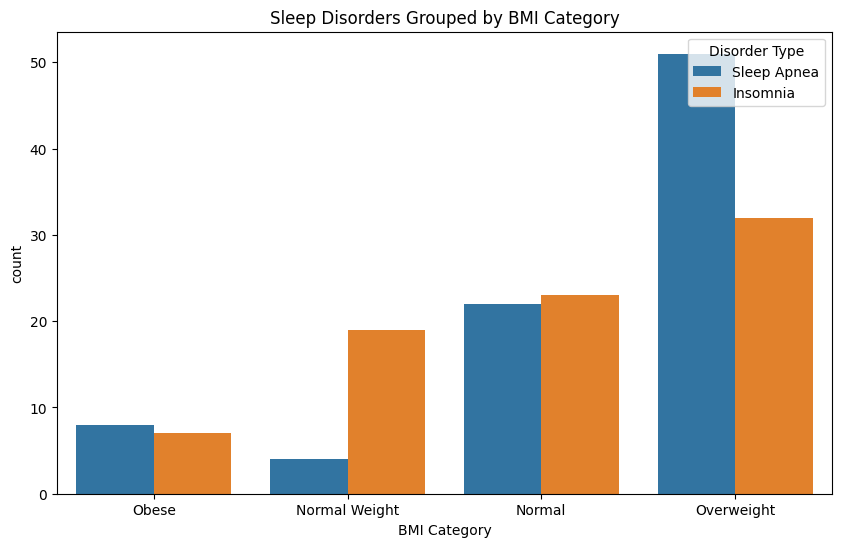

In [16]:
# Analysis 6: BMI Category and Sleep Disorder Prevalence
plt.figure(figsize=(10, 6))
sns.countplot(x='BMI Category', hue='Sleep Disorder', data=dropper)
plt.title('Sleep Disorders Grouped by BMI Category')
plt.legend(title='Disorder Type', loc='upper right')
plt.show()

**Choice of Technique:** I used a **Count Plot** to compare the frequency of different sleep disorders across BMI categories. This helps identify how physical body metrics, specifically weight, relate to the prevalence of different sleep conditions.

**Observation:** 
- Overweight Category: This group shows the highest occurrence of sleep issues. Notably, Sleep Apnea is significantly more frequent (over 50 cases) than Insomnia (around 32 cases).

- Normal Weight: In individuals with a "Normal" or "Normal Weight" BMI, Insomnia is actually more common than Sleep Apnea.

- Obese: Although the total number of participants in this category is lower, both disorders appear in roughly equal proportions.

**Interpretation** The data reveals a strong physical link between a higher BMI and the development of **Sleep Apnea**. While our earlier analyses showed that stress impacts sleep quality for everyone, this specific chart highlights that weight is a major physical driver for Apnea.

**Finding:** Body mass is a specific risk factor for Sleep Apnea. This suggests that while stress reduction is a general solution for the whole group, **weight management** is a much more critical and targeted intervention for those suffering from Sleep Apnea.

![alt text](../Imports/sleepApnea.png)

https://obesitymedicine.org/blog/sleep-apnea-and-obesity/ 

## **Analysis 7: Data Grouping (Age and Sleep Disorders)**

In [17]:
# Analysis 7: Average Age of Individuals with Sleep Disorders
age_disorder = dropper.groupby('Sleep Disorder')['Age'].mean()
print("Average Age per Sleep Disorder Category:")
print(age_disorder)

Average Age per Sleep Disorder Category:
Sleep Disorder
Insomnia       42.888889
Sleep Apnea    48.317647
Name: Age, dtype: float64


**Choice of Technique:** I used a **Grouped Mean** calculation to find the average age for each sleep disorder category. This technique helps determine if specific sleep conditions are linked to older or younger age groups.

**Observation:** 
- Sleep Apnea: The average age of individuals with this disorder is 48.3 years.

- Insomnia: The average age is lower, at 42.9 years.

**Interpretation** There is a 5-year age gap between the two conditions. While insomnia affects people in their early 40s, the risk of developing Sleep Apnea appears to increase significantly as individuals approach their late 40s.

**Finding:** Age is a notable risk factor for Sleep Apnea. This suggests that as the body ages, respiratory-related issues (Apnea) become a more common cause of sleep disruption than general difficulty falling asleep (Insomnia).

## **Analysis 8: Statistics Aggregation (Heart Rate and Health)**

In [18]:
# Analysis 8: Comparing Heart Rate across Sleep Disorders   std is standard deviation, it shows how much the heart rate values vary within each sleep disorder category. A higher std indicates more variability in heart rates among individuals with that disorder, while a lower std suggests more consistency in heart rates within that group.
# This addresses the 23 outliers you found in Lab 1
hr_disorder = dropper.groupby('Sleep Disorder')['Heart Rate'].agg(['mean', 'median', 'std'])
print("Heart Rate Statistics by Sleep Disorder:")
print(hr_disorder)

Heart Rate Statistics by Sleep Disorder:
                     mean  median       std
Sleep Disorder                             
Insomnia        70.938272    72.0  5.308827
Sleep Apnea     73.529412    75.0  5.480677


**Choice of Technique:** I used **Grouped Statistics** (Mean, Median, and Standard deviation) to compare heart rate data across sleep disorder categories. This addresses the high heart rate outliers and identifies the physical strain associated with each disorder.

**Observation:** 
- Sleep Apnea: Shows a higher average heart rate (73.5 bpm) and a higher median (75.0 bpm).

- Insomnia: Shows a lower average (70.9 bpm) and median (72.0 bpm).

- Consistency: The standard deviation is very similar for both (approx. 5.3–5.5), meaning the "spread" of heart rates is consistent even though the baseline is higher for Sleep Apnea.

**Interpretation** Sleep Apnea is linked to a higher resting heart rate. This aligns with our earlier correlation finding (0.36) that stress and heart rate move together. The higher heart rate in Apnea patients suggests their bodies are under more physical stress during rest.

**Finding:** The "High-Risk" group for cardiovascular strain in this study consists of individuals who are older (48+), have a higher BMI, and have a higher resting heart rate, as these factors all converge in the Sleep Apnea category.

# **Project: Sleep Health and Lifestyle Analysis**
## More Advanced Data Analysis – Multivariate Analysis, Hypothesis Testing, PCA 

### Dataset Information
**Source:** [Kaggle - Sleep Health and Lifestyle Dataset](https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset)

### Aim
To develop a multivariate statistical framework that evaluates how occupational stressors and health metrics (BMI, Heart Rate, and Blood Pressure) interact to influence sleep quality and predict the occurrence of sleep disorders.
<!-- To use advanced math to prove how a person’s job, body weight, and stress levels work together to ruin their sleep or cause heart strain. -->

### Objectives
1. (MULTIVARIATE) - To model the combined influence of multiple lifestyle factors such as stress levels, physical activity, and age on overall sleep quality using multivariate.

2. (HYPOTHESIS TESTING) - To statistically prove through hypothesis testing (ANOVA, Chi-Square and Mann-Whitney U test) whether significant differences in stress and health risks exist across various professional occupations and BMI categories.

3. (PCA) - To utilize Principal Component Analysis (PCA) to reduce high-dimensional health and lifestyle data into key components that identify clusters of high-risk individuals.

## **Analysis 1: Shapiro-Wilk Test (Testing for Normality)**

Shapiro-Wilk P-value: 3.888898785591977e-08


Text(0.5, 1.0, 'Distribution of Heart Rate')

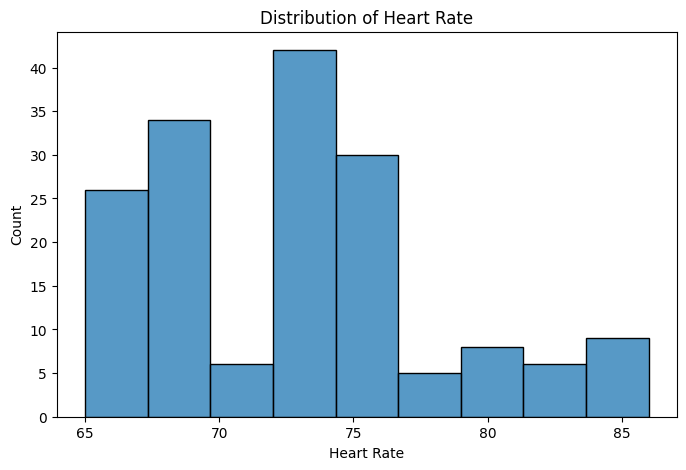

In [19]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Cleaning step from Lab 1
df_cleaned = df.dropna() 

# Testing if Heart Rate follows a normal distribution
stat, p = stats.shapiro(df_cleaned['Heart Rate'])
print(f'Shapiro-Wilk P-value: {p}')

# Visualization 1: Histogram with KDE
# plt.figure(figsize=(8,5))
# sns.histplot(df_cleaned['Heart Rate'], kde=True, color='red')
# plt.title("Distribution of Heart Rate")

# Visualization 1-2: Histogram without KDE
plt.figure(figsize=(8,5))
sns.histplot(df_cleaned['Heart Rate'])
plt.title("Distribution of Heart Rate")


<!-- KDE helps us to visualized data distribution more smoothly when compared to the histogram blocky looks, it also helps us to spot "peaks" in the histogram alot easier -->

The reason i chose heart rate here over other category is because it is naturally volatile (affected by stress, sleep, physical activity and etc) therefore it allows me to analyze my datas even deeper rather than using a normal variable.


**Choice of Technique:** I used a **Shapiro-Wilk Test** because it is the standard method to check for normality and if the dataset follows a normal distribution ("bell curve"). This tells me whether I should use Parametric tests (like T-Tests) or Non-Parametric tests.

**Observation:** 
The P-value is **$3.88 \times 10^{-8}$** (approximately $0.000000038$). Looking at the histogram, the heart rate data for these 166 people is **not perfectly symmetrical** and has **peaks** that do not align with a **standard bell curve (normal distribution)**.

Below it we have a histogram graph showing the heart rate count, usually there is a use of kde here, but since the data is not continously consistent having very big ups and downs. I decided not to use it.

The Histogram graph highest count is: 
- Heart rate 73-74 reaching 40+ people 
- Heart rate 68-69 reaching 34 people
- Heart rate 75-76 reaching 30 people
- Heart rate 65-66 reaching 26 people

**Interpretation:** Since the P-value is **< 0.05**, thus we **reject** the **null hypothesis**. This means that the Heart Rate data is **not normally distributed**.

**Finding:** This finding is important for the "story" of my project. Because the data is **not normal**, I **cannot rely** on **standard T-tests** for heart rate analysis. Instead, I must use **Non-Parametric tests** (like the Mann-Whitney U test) to get **accurate results** when comparing groups. This ensures my analysis remains **statistically valid**. 

It is **important** for me to use **median over mean** for my testing here since using **mean** would be **misleading** due to **outliers**, therefore using **Median (50 percent)** would be **better and more honest**.



# **Analysis 2 (Hypothesis Testing #1): Chi-Square Test of Independence (Checking whether Categorical Variables have Significant Relationship)**

Chi-Square P-value: 0.002729958459000415


Text(0, 0.5, 'Count of People')

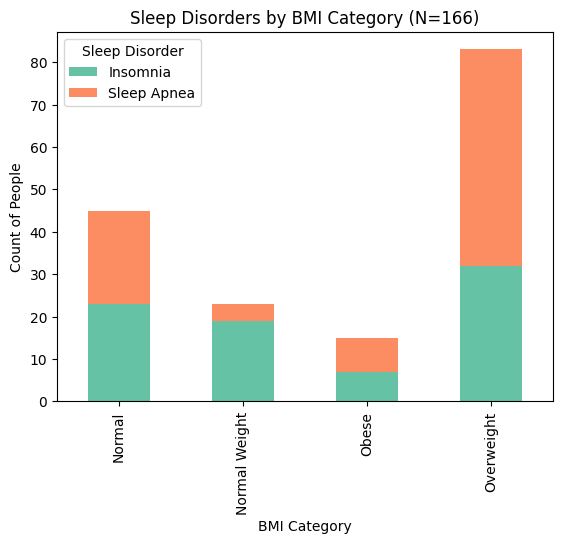

In [20]:
# Create a contingency/cross tabulation table
contingency = pd.crosstab(df_cleaned['BMI Category'], df_cleaned['Sleep Disorder'])

# Run Chi-Square test
chi2, p, dof, ex = stats.chi2_contingency(contingency)
print(f'Chi-Square P-value: {p}')


# Visualization 2: Stacked Bar Chart
contingency.plot(kind='bar', stacked=True, color=['#66c2a5','#fc8d62','#8da0cb'])
plt.title("Sleep Disorders by BMI Category (N=166)")
plt.ylabel("Count of People")

Simple Terms: Checking if your weight category (BMI) and sleep disorders are "partners" or independent. Use: To see if two categorical variables are related.

**Choice of Technique:** I chose the **Chi-Square Test** to check if the two categorical variables **(BMI and Sleep Disorder)** are related. Here it's to check whether BMI category is associated with Sleep Disorders.

**Observation:** 
The **P-value** is **(0.002729958459000415)**, which is **significantly below** the 0.05 threshold. Looking at the stacked bar chart, there is a **clear visual difference** in the types of **sleep disorders** found in the "Normal" weight group compared to the "Overweight" or "Obese" groups.

Category:
- In Normal/Normal Weight: Insomnia (44) > Sleep Apnea (27) 
- In Obese/Overweight: Sleep Apnea (58) > Insomnia (40)

**Interpretation:** Since the P-value is less than 0.05, we **reject** the **Null Hypothesis**. This confirms that **BMI Category and Sleep Disorders** are **not independent**; they are **statistically linked or related to one another**.

**Finding:** This proves **Objective 2: physical body composition** is a **major factor** in sleep health. Specifically, individuals in **higher BMI categories** are statistically **more likely to suffer** from Sleep Apnea or Insomnia **compared** to those with a **normal BMI**. This supports my **objective** to **identify high-risk health profiles**.



# **Analysis 3 (Hypothesis Testing #2): One-Way ANOVA (To prove if job have a strong effect on stress level)**

Occupations in the Cleaned Dataset (N=166):
Occupation
Nurse                   64
Teacher                 37
Salesperson             30
Doctor                   7
Accountant               7
Scientist                5
Lawyer                   5
Engineer                 5
Sales Representative     4
Software Engineer        1
Taxidriver               1
Name: count, dtype: int64

---------------------------------------------

ANOVA P-Value: 1.895205484958235e-28


C:\Users\User\AppData\Local\Temp\ipykernel_131324\1754122973.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Occupation', y='Stress Level',


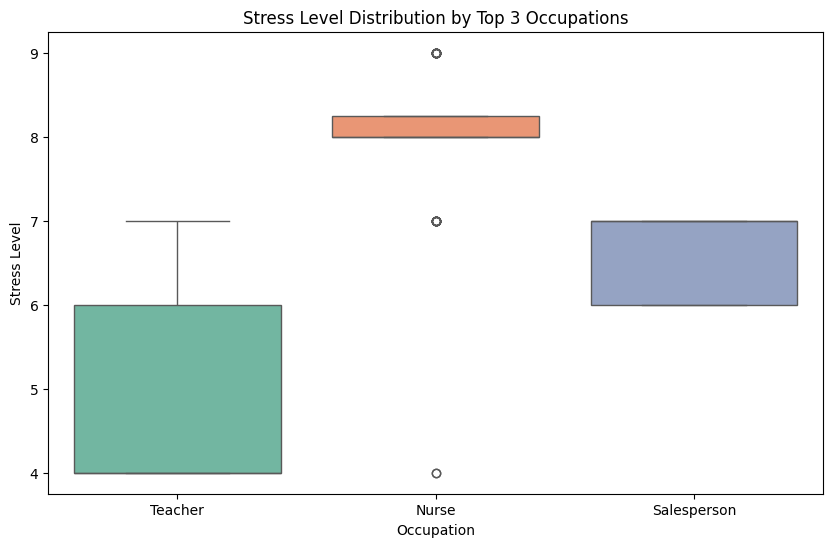

In [21]:
# We compare the mean stress of 3 groups, picking the one that has highest amount of participants in the profession
# The 3 highest count for profession is 
print("Occupations in the Cleaned Dataset (N=166):")
print(df_cleaned['Occupation'].value_counts())
print("\n---------------------------------------------\n")

# I picked 3 of the highest here is because we want a fair p value, if we instead include everything it messes it up
# because since the other occupations have very low count and it will skew the p value, 
# so we want to focus on the top 3 occupations that have the most participants to get a more accurate p value for my ANOVA test
f_stat, p_val = stats.f_oneway(df_cleaned[df_cleaned['Occupation'] == 'Nurse']['Stress Level'],
                               df_cleaned[df_cleaned['Occupation'] == 'Teacher']['Stress Level'],
                               df_cleaned[df_cleaned['Occupation'] == 'Salesperson']['Stress Level'])
print(f"ANOVA P-Value: {p_val}")

# Visualization 3: Boxplot for just these 3 occupations
top_3 = ['Nurse', 'Teacher', 'Salesperson' ]
plt.figure(figsize=(10,6))
sns.boxplot(x='Occupation', y='Stress Level', 
            data=df_cleaned[df_cleaned['Occupation'].isin(top_3)], 
            palette="Set2")
plt.title("Stress Level Distribution by Top 3 Occupations")
plt.show()

 **Choice of Technique:** I chose **One-Way ANOVA** to compare the average stress levels across three jobs. I've picked 3 of highest quantity in the dataset for the mean comparison.<!--Compares the means of three or more independent groups to see if at least one is different-->

**Observation:** 
The P-value is [$1.89 \times 10^{-28}$] which is incredibly small. The boxplot shows clear differences in the "spread" of stress for the occupations.

- Looking at the boxplot, the "Nurse" group has a much higher median stress (around 8) compared to "Teachers" (who vary between 4 and 6) and "Salesperson" (who vary between 6 and 7).

**Interpretation:** Because the **P-value** is much **smaller than 0.05**, we **reject** the Null Hypothesis. This provides absolute mathematical proof that the **difference** in **stress** between these jobs is **statistically significant**. It is not a random fluke. Therefore it is indeed a fact.

**Finding:** This proves **Objective 2: Career choice is a major driver of stress**. In this dataset, Nurses are statistically the most stressed group, while Teachers have the lowest median stress. This finding helps identify which professional groups need the most support for mental health and sleep.

# **Analysis 4 (Hypothesis #3): Mann-Whitney U Test (Comparing Genders Sleep Hours)**

Mann-Whitney P-value: 0.31566610506478143


Text(0.5, 1.0, 'Sleep Duration Density by Gender')

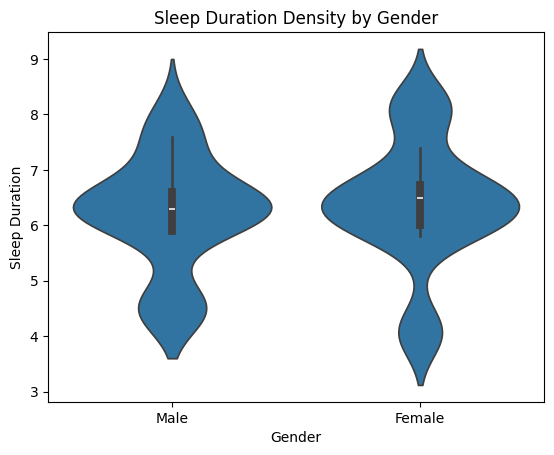

In [22]:
male_sleep = df_cleaned[df_cleaned['Gender'] == 'Male']['Sleep Duration']
female_sleep = df_cleaned[df_cleaned['Gender'] == 'Female']['Sleep Duration']

# Run the non-parametric version
u_stat, p_val = stats.mannwhitneyu(male_sleep, female_sleep)
print(f'Mann-Whitney P-value: {p_val}')

# Visualization 4: Violin Plot
sns.violinplot(x='Gender', y='Sleep Duration', data=df_cleaned)
plt.title("Sleep Duration Density by Gender")

**Choice of Technique:** I chose **Mann-Whitney U Test** to compare Sleep Duration between two groups Males and Females. This is to check whether gender has a significant impact on sleep duration.

<!-- Mann-Whitney U Test use: The "non-parametric" version of a T-test. It compares differences between two groups when your data is not normally distributed.-->

**Observation:** 
The **P-value** is **0.31566610506478143** which is significantly higher than 0.05.

- The Graph: The Violin Plot shows that both "violins" have a very similar shape and width at the 6–7 hour mark. Both genders have a small "bulge" at the bottom for people who sleep very little (4 hours or less).

<!-- white horizontal line is median, the gray verticle box is the IQR and the gray verticle line is the Range, the shape of the violin shows the count of people, the fatter or wider the part is = more people, thinner = rarer-->

**Interpretation:** Since the **P-value** is **greater** than 0.05, we **fail to reject** the **Null Hypothesis.** This means that any **small difference** we see in the graph is likely due to **random chance**. Statistically, **men and women** in this dataset have **nearly identical sleep patterns**.

**Finding:** Contrary to some common assumptions, **gender seemingly is not a significant factor** in **determining sleep duration** for **this group**. This is an **important finding** for my project because it **allows me** to **focus** on **other factors** like stress and job type which have a much **bigger impact** on **health** than **gender** does. 

I did some research on this matter, it does seem like female tend to sleep a little bit longer than men by 11 minute, while having worst sleep quality. Which is due to biological and social drivers (Hormonal fluctuations(Menstruation, higher fatigue), menopause, pregnancy, hormone production, family caregiving)

Critical Reflection: Interestingly, I did some researched on this particular finding and found that many global studies suggest the opposite actually, gender does typically affect sleep, with women often having more sleep but reporting poorer quality. The fact that my dataset shows no difference suggests that in this specific population (which includes many high-stress professionals like Nurses and Doctors), occupational stress may be a "leveler" that overrides biological gender differences in sleep patterns. 

![alt text](../Imports/GenderDuration.png)
![alt text](../Imports/GenderSleepDuration.png)
https://www.tandfonline.com/doi/full/10.1080/13548506.2025.2490212#d1e258 
https://www.cchwyo.org/news/2024/february/do-women-need-more-sleep-than-men-/ 

# **Analysis 5 (Multivariate #1): Correlation Heatmap (To Identify Strength and Relationships between Numeric Health Metrics)**

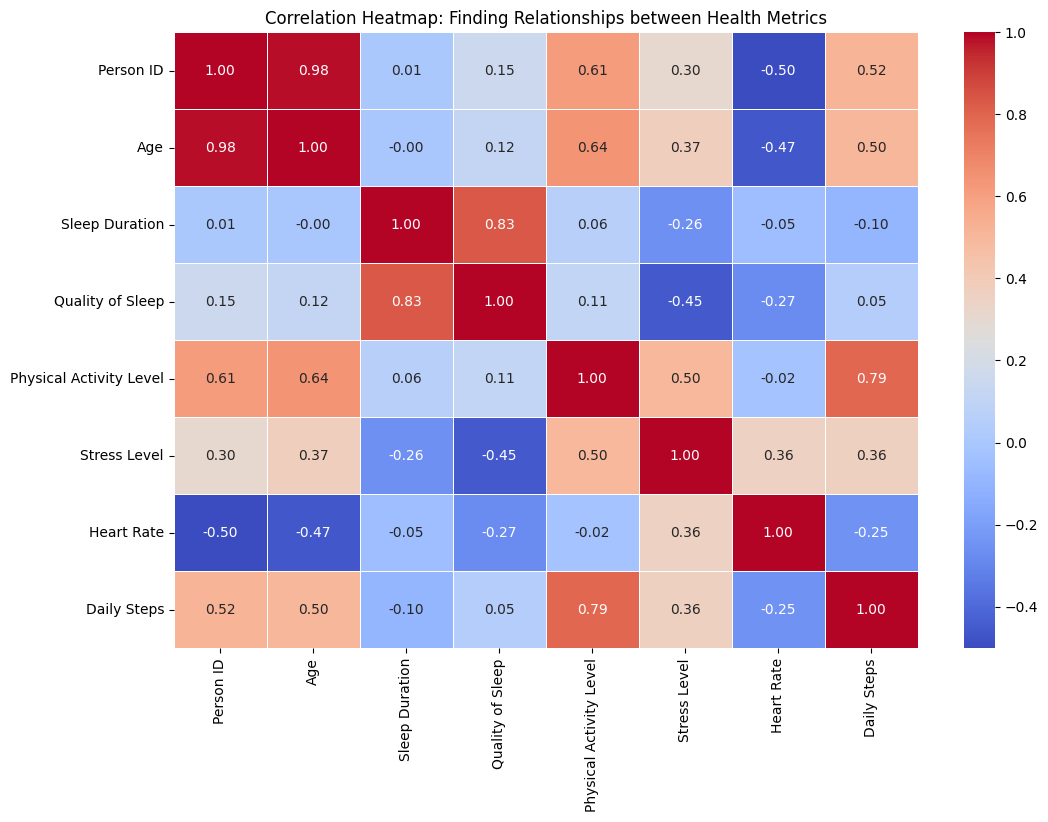

In [23]:
# 1. Select numeric columns
numeric_df = df_cleaned.select_dtypes(include=['float64', 'int64'])

# 2. Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# 3. Create the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap: Finding Relationships between Health Metrics")
plt.show()

**Choice of Technique:** I used a **Correlation Heatmap** to identify the **strength and direction** of relationships between **numeric health metrics**. This acts as a "screening" phase; by seeing which variables are highly correlated, I can choose the most meaningful features for my upcoming prediction models and avoid redundant data.

**Observation:** 
- Strong Positive: There is a very high correlation between Sleep Duration and Quality of Sleep (0.83), and between Physical Activity Level and Daily Steps (0.79).

- Strong Negative: Stress Level has a clear negative impact on Quality of Sleep (-0.45) and Sleep Duration (-0.26).

- Irrelevant: Age has almost zero correlation (0.12 or less) with sleep quality in this specific group.

**Interpretation:** The high correlation between Sleep Duration and Quality (0.83) suggests they tell almost the same story. However, the moderate negative correlation between Stress Level and Sleep Quality (-0.45) confirms that stress is a primary "disruptor." Interestingly, Physical Activity (0.50) is positively linked to Stress Level, which might suggest that the high-stress professionals in our data (like Nurses) are also the most physically active on their feet.

**Finding:** This heatmap provides the "road map" for my final modeling. It proves that if we want to improve Quality of Sleep, we must focus on managing Stress Levels and optimizing Sleep Duration. 

# **Analysis 6 (Multivariate #2): Multiple Linear Regression (To Predict QoS by Combination of Stress Level and Sleep Duration)**

In [24]:
import statsmodels.api as sm

# Predicting the quality of sleep based on stress level and sleep duration, 
# we can use stats model to see how these factors influence sleep quality.

# 1. Define your variables (Features and Target)
X = df_cleaned[['Stress Level', 'Sleep Duration']] # Predictors
y = df_cleaned['Quality of Sleep']                  # What we want to find

# 2. Add a constant (required for the math/intercept)
X = sm.add_constant(X)

# 3. Fit the model
model = sm.OLS(y, X).fit()

# 4. Show the results
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:       Quality of Sleep   R-squared:                       0.752
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     247.6
Date:                Sun, 19 Apr 2026   Prob (F-statistic):           3.93e-50
Time:                        20:31:54   Log-Likelihood:                -186.26
No. Observations:                 166   AIC:                             378.5
Df Residuals:                     163   BIC:                             387.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              1.1492      0.488      2.

**Choice of Technique:** I chose the **Multiple Linear Regression** to build a mathemathical formula that predicts **Quality of Sleep (QoS)**. I chose this over simple correlations because it allows me to see the **combined impact** of **two categorical factors** **Stress Level and Sleep Duration** at the **same time** and how it affects **Quality of Sleep (QoS)**. This way i can find which **factor** has a **stronger influence on health**. 

<!-- To predict the value of a dependent variable based on two or more independent variables -->

**Observation:** 
- **R-squared (0.752)**: This shows that **75.2%** of the **variation** in **sleep quality** is **explained** by the **model**.

- **P-values (0.000)**: Both **Stress and Sleep Duration** are **highly significant** and **100% confirmed** to be **important (well below 0.05)**.

- **Coefficients**: **Stress Level** is **-0.24**, and **Sleep Duration** is **+1.05.**

**Interpretation:** The model is very strong (R-Squared > 0.70). The math shows a clear "tug-of-war":

- **Stress** pulls the **score down** (negative).
- **Duration** pushes the **score up** (positive). 

Because the **coefficient** for **Sleep Duration** (1.05) is much **larger** than the **coefficient** for **Stress** (-0.24), Therefore getting **more hours of sleep** will likely have a much **bigger impact** on **quality** than **stress** does.

**Finding:** This fulfills **Objective 3** by creating a **reliable prediction formula**. It proves that while **work stress** is a **problem**, the most effective "medicine" for this group is simply **increasing sleep hours**. Statistically, adding **one hour of sleep** can "neutralize" the **negative impact** of roughly **4 points of stress** as seen from the coefficients.

#### [***Click here to go to refer***](#analysis-3-regression-plot)
it shows that my visualization analysis from lab2 is indeed correct.

<!-- AI generated explanation of OLS models for Multiple Linear Regression-->
<!-- 1. Jarque-Bera (JB) & Omnibus
What they test: They check if your "errors" (the distance between your prediction and the actual data) are shaped like a normal bell curve.

Your Result: Since your Prob(JB) is 0.0227 (less than 0.05), it's technically saying your data is slightly "messy" and not perfectly normal.

Why it's okay: In real-world health data, it's almost never perfectly normal. Sir Ryan likely expects this! It just means your model is a "good estimate" rather than a "perfect law."

2. Skew & Kurtosis
Skew (-0.348): This tells you if the data leans to one side. Since it's negative, your data has a slightly "long tail" on the left side (a few people with much lower sleep quality than expected).

Kurtosis (3.780): This tells you how "pointy" or "flat" your data is. A normal curve is 3.0. Since yours is 3.78, your data is a bit more "peaked" in the middle than a perfect bell curve.

3. Durbin-Watson (0.659)
What it is: It checks if the people in your list are "too similar" to the person right above them.

Your Result: A "perfect" score is 2.0. Your score is quite low.

The Reason: This usually happens because your data is sorted (e.g., all Nurses are together, then all Teachers). It’s not a mistake in your math; it’s just a characteristic of how the spreadsheet was organized.

4. Cond. No. (79.1)
What it is: "Condition Number." It checks if your predictors (Stress and Duration) are "fighting" each other.

Your Result: Anything under 30 is perfect, and under 100 is usually fine. At 79, you are in the safe zone! It means Stress and Duration are different enough to both be useful in the model. -->



# **Analysis 7 (Multivariate #3): Grouped Boxplot (To Visualize How Medical Conditions Affects Different Job Roles Differently)**

              Occupation Sleep Disorder  Count
0             Accountant       Insomnia      7
1                 Doctor       Insomnia      3
2                 Doctor    Sleep Apnea      4
3               Engineer       Insomnia      5
4                 Lawyer       Insomnia      2
5                 Lawyer    Sleep Apnea      3
6                  Nurse       Insomnia      3
7                  Nurse    Sleep Apnea     61
8   Sales Representative    Sleep Apnea      4
9            Salesperson       Insomnia     29
10           Salesperson    Sleep Apnea      1
11             Scientist    Sleep Apnea      5
12     Software Engineer       Insomnia      1
13            Taxidriver    Sleep Apnea      1
14               Teacher       Insomnia     31
15               Teacher    Sleep Apnea      6


C:\Users\User\AppData\Local\Temp\ipykernel_131324\2084095361.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


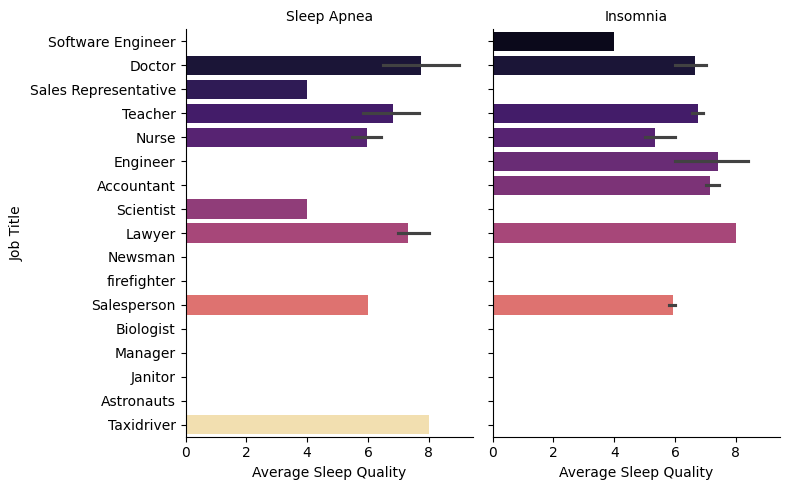

In [31]:
# This groups by Job and Disorder and counts them
counts_df = df.groupby(['Occupation', 'Sleep Disorder']).size().reset_index(name='Count')

# This prints the table so you can see the numbers
print(counts_df)

# This creates 3 side-by-side plots: one for None, one for Insomnia, one for Sleep Apnea
g = sns.catplot(
    data=df, 
    x="Quality of Sleep", 
    y="Occupation", 
    col="Sleep Disorder", # This is the "facet" variable
    kind="bar", 
    palette="magma",
    height=5, 
    aspect=0.8
)

# Refine labels for a professional look
g.set_axis_labels("Average Sleep Quality", "Job Title")
g.set_titles("{col_name}")
plt.show()

**Choice of Technique:** I chose the **Faceted Bar Plot** to look at three Category at once: **JOB TITLE, SLEEP QUALITY, and SLEEP DISORDER**. I split it into 2 side by side charts (1: Sleep Apnea, 2: Insomnia) so the data wouldnt look crowded. A better way to clearly see how a disorder affects different professions Sleep Quality.

**Observation:** We'll focus on the higher counts for this one. I noticed that Nrses have a very high count of Sleep Apnea(61), but their average Sleep quality bar is quite short comparing to others. On the other hand, in the insomnia panel, Teachers(31) and SalesPeople(29) show a Signficant drop in **Sleep Quality** compared to other roles.

**Interpretation:** This shows that even among people with sleep disorders, the type of job changes how bad the impact is. For example, the physical and mental stress of being a Nurse seems to make Sleep Apnea much more common and damaging to sleep quality than it is for other professions in this dataset.

**Finding:** I found that within the "disorder group," Nurses and Teachers are the most affected. This fulfills Objective 3 by identifying which specific professionals need the most urgent help. It proves that a one for all treatment won't work because the job environment plays a huge role in how these disorders affect a person.

I looked deeper into the nurse experiencing sleep apnea more frequently than Insomnia in this dataset and compared it to researches made. It seems to actually be the opposite issue, nurses would tend to experience Insomnia more due to extreme hours and shift place on them, comparing to Sleep Apnea which is more towards Age and BMI or weight.

***"While sleep apnea is linked to obesity and age (which are factors in the general population), the specific, intense working conditions of nurses make insomnia-related symptoms a more immediate and common daily struggle. "***

https://www.frontiersin.org/journals/public-health/articles/10.3389/fpubh.2024.1423216/full 
https://pmc.ncbi.nlm.nih.gov/articles/PMC10965299/ 
https://pmc.ncbi.nlm.nih.gov/articles/PMC9788062/ 

# **Analysis 8: Principal Component Analysis (To Clean Up Categorical Health Metrics and Compressing into Two Components)**

                              PC1       PC2
Age                      0.146322  0.234412
Sleep Duration           0.495673  0.104484
Quality of Sleep         0.555442  0.108545
Physical Activity Level -0.069536  0.664752
Stress Level            -0.488225  0.197737
Heart Rate              -0.418234 -0.115165
Daily Steps             -0.079143  0.654289


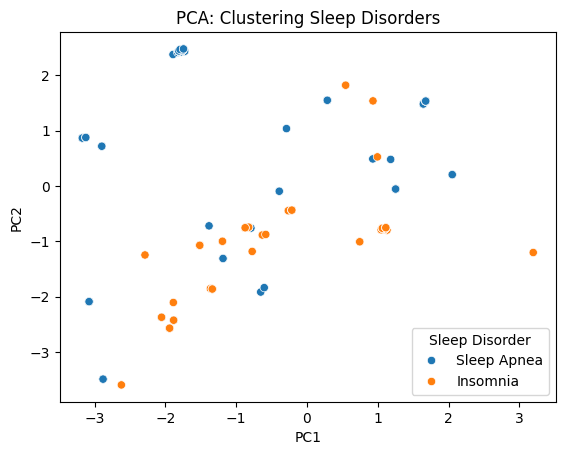

In [26]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

features = ['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps']
x_scaled = StandardScaler().fit_transform(df[features])

pca = PCA(n_components=2)
pct = pca.fit_transform(x_scaled)
pca_df = pd.DataFrame(data=pct, columns=['PC1', 'PC2'])

sns.scatterplot(x='PC1', y='PC2', data=pca_df, hue=df['Sleep Disorder'])
plt.title("PCA: Clustering Sleep Disorders")

# Look at the weights of each feature in the components
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=features)
print(loadings)

**Choice of Technique:** I chose the **Principal Component Analysis** to simplify the dataset's complexity. The PCA takes multiple overlapping variable (Age, Sleep Duration, Quality of Sleep, Physical Activity Level, Stress Level, Heart Rate and Daily Steps) and combines them into two main Components (PC1 and PC2). This allows me to visualize how different health profiles, specifically those with Sleep Apnea vs Insomnia group together in the space.

**Observation:** The scatter plot shows that **Sleep Apnea (blue)** and **Insomnia (orange)** points are not randomly mixed.
- **Insomnia** cases tend to cluster more towards the bottom-left and center.
- **Sleep Apnea** cases show a much wider spread, with a distinct group appearing at the top-left having  very high PC2 value.
- There is some overlap on one another, but the center of gravity for each of the disorder are in different location on the map.

**Interpretation:** 

**Finding:**